# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "alumno01", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

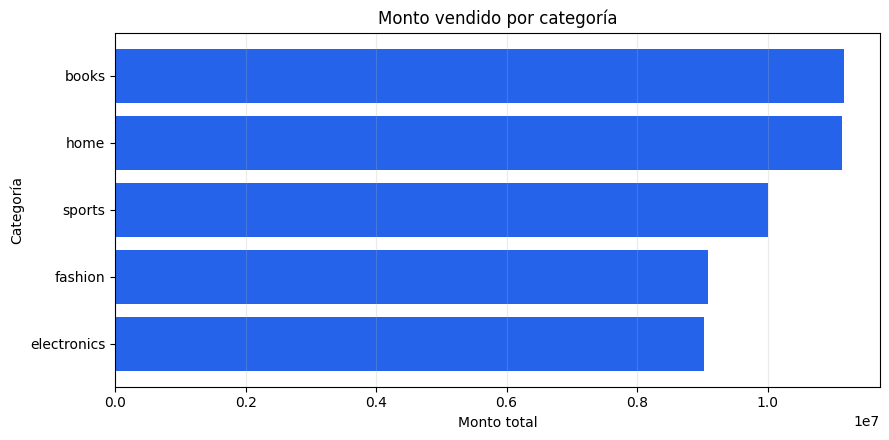

Respuesta: books es la categoría con mayor monto vendido (11,165,281.86).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

Máx. monto: 2026-03-01 → 7,310,840.77 USD (7236 trx, ticket 1,010.34)
Máx. trx:   2026-03-01 → 7236 trx (7,310,840.77 USD, ticket 1,010.34)
Ticket promedio del período: 1001.63
¿Coinciden? True


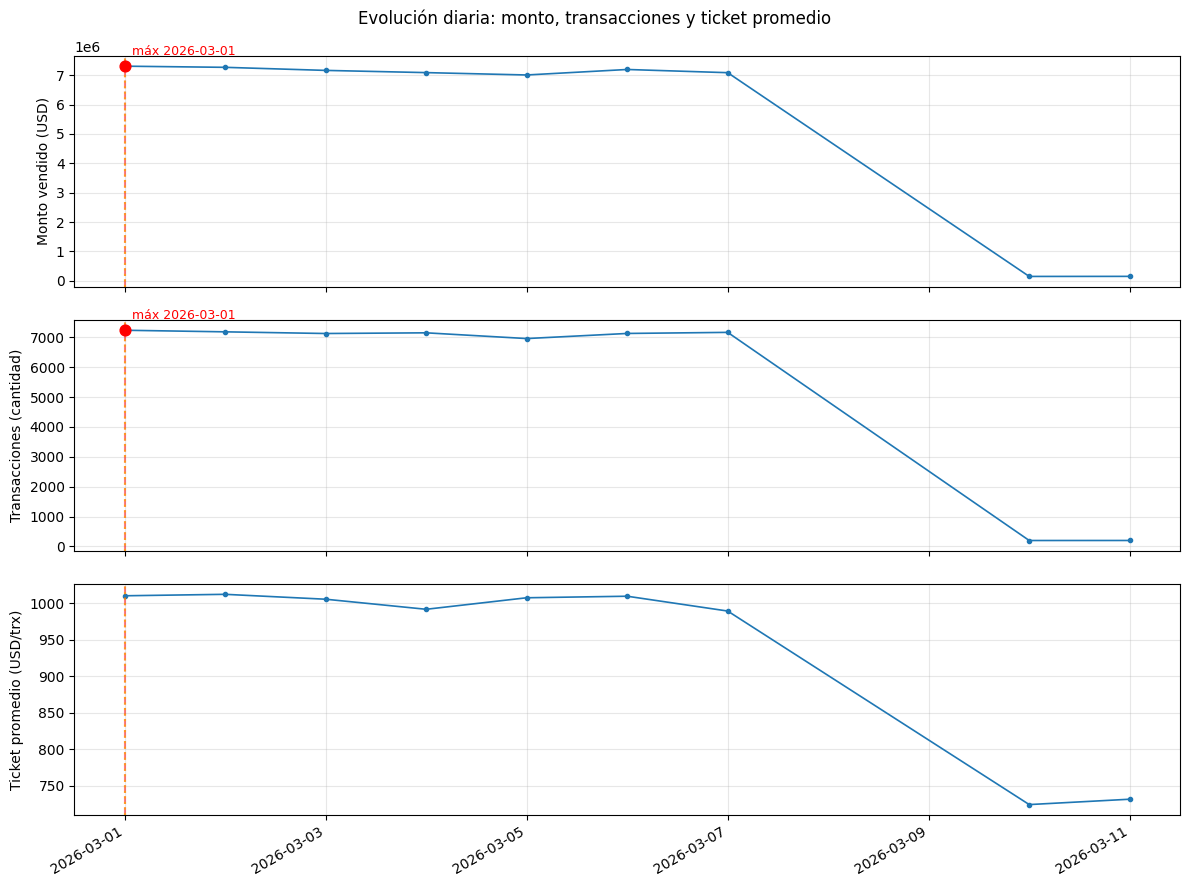

In [0]:
spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA bigdata_federico")

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

daily = (
    spark.table("gold_daily_sales")
    .groupBy("sale_date")
    .agg(
        F.sum("total_amount").alias("monto"),
        F.sum("transaction_count").alias("trx"),
    )
    .withColumn("ticket_promedio", F.col("monto") / F.col("trx"))
    .orderBy("sale_date")
)
pdf = daily.toPandas()

d_monto = pdf.loc[pdf["monto"].idxmax()]
d_trx   = pdf.loc[pdf["trx"].idxmax()]
print(f"Máx. monto: {d_monto.sale_date} → {d_monto.monto:,.2f} USD ({d_monto.trx:.0f} trx, ticket {d_monto.ticket_promedio:,.2f})")
print(f"Máx. trx:   {d_trx.sale_date} → {d_trx.trx:.0f} trx ({d_trx.monto:,.2f} USD, ticket {d_trx.ticket_promedio:,.2f})")
print("Ticket promedio del período:", round(pdf["monto"].sum() / pdf["trx"].sum(), 2))
print("¿Coinciden?", d_monto.sale_date == d_trx.sale_date)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
series = [
    ("monto", "Monto vendido (USD)", d_monto),
    ("trx", "Transacciones (cantidad)", d_trx),
    ("ticket_promedio", "Ticket promedio (USD/trx)", None),
]
for ax, (col, label, maxrow) in zip(axes, series):
    ax.plot(pdf["sale_date"], pdf[col], marker="o", markersize=3, linewidth=1.2)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    if maxrow is not None:
        ax.scatter(maxrow.sale_date, maxrow[col], color="red", s=60, zorder=3)
        ax.annotate(f"máx {maxrow.sale_date}", (maxrow.sale_date, maxrow[col]),
                    textcoords="offset points", xytext=(5, 8), color="red", fontsize=9)
for ax in axes:
    ax.axvline(d_monto.sale_date, color="red", linestyle="--", alpha=0.5)
    ax.axvline(d_trx.sale_date, color="orange", linestyle=":", alpha=0.7)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
fig.suptitle("Evolución diaria: monto, transacciones y ticket promedio")
plt.tight_layout()
plt.show()

El dia 1/3/2026 fue el que tuvo mas transacciones y mas monto vendido.

## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

payment_channel   trx participacion_trx  fraudes tasa_fraude ic_inf ic_sup
       transfer 16723             33.2%     2327      13.91% 13.40% 14.45%
         wallet 16724             33.2%     2169      12.97% 12.47% 13.49%
           card 16902             33.6%     2119      12.54% 12.05% 13.04%

Tasa global de fraude: 13.14%


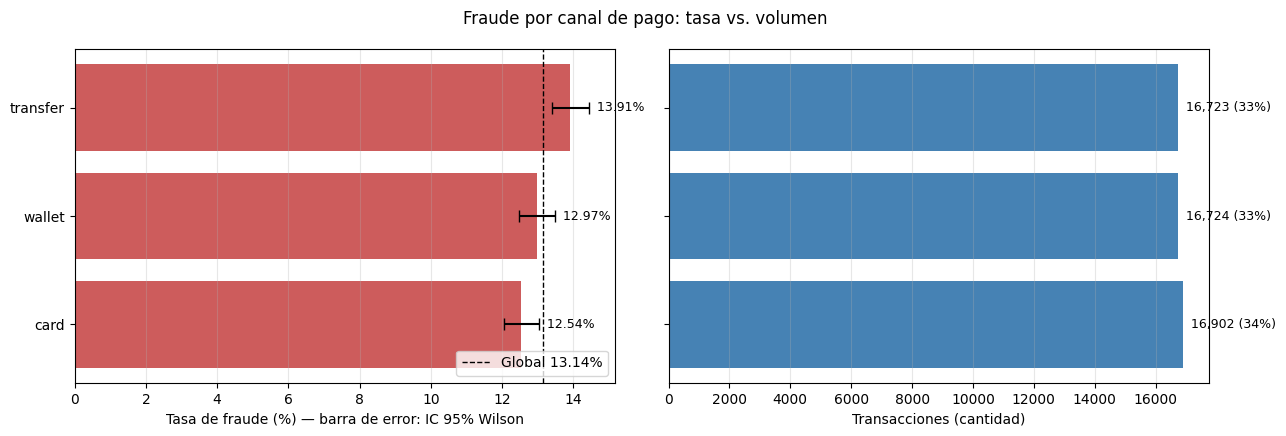

In [0]:
spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA bigdata_federico")

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np

# 1) Agregar por canal: tasa = suma de fraudes / suma de transacciones (no promedio de fraud_rate)
canal = (
    spark.table("gold_daily_sales")
    .groupBy("payment_channel")
    .agg(
        F.sum("transaction_count").alias("trx"),
        F.sum("fraud_transactions").alias("fraudes"),
    )
    .withColumn("tasa_fraude", F.col("fraudes") / F.col("trx"))
    .orderBy(F.desc("tasa_fraude"))
)
pdf = canal.toPandas()

# 2) Intervalo de confianza de Wilson 95% para cada tasa
z = 1.96
n, p = pdf["trx"].astype(float), pdf["tasa_fraude"].astype(float)
centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
pdf["ic_inf"], pdf["ic_sup"] = centro - margen, centro + margen
pdf["participacion_trx"] = pdf["trx"] / pdf["trx"].sum()

tasa_global = pdf["fraudes"].sum() / pdf["trx"].sum()
print(pdf[["payment_channel", "trx", "participacion_trx", "fraudes", "tasa_fraude", "ic_inf", "ic_sup"]]
      .to_string(index=False, formatters={
          "participacion_trx": "{:.1%}".format, "tasa_fraude": "{:.2%}".format,
          "ic_inf": "{:.2%}".format, "ic_sup": "{:.2%}".format}))
print(f"\nTasa global de fraude: {tasa_global:.2%}")

# 3) Visualización: tasa con IC (izq) y volumen (der), mismo orden de canales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 0.8 * len(pdf) + 2), sharey=True)
y = np.arange(len(pdf))
err = [pdf["tasa_fraude"] - pdf["ic_inf"], pdf["ic_sup"] - pdf["tasa_fraude"]]

ax1.barh(y, pdf["tasa_fraude"] * 100, xerr=[e * 100 for e in err], capsize=4, color="indianred")
ax1.axvline(tasa_global * 100, color="black", linestyle="--", linewidth=1, label=f"Global {tasa_global:.2%}")
for i, r in pdf.iterrows():
    ax1.text(r.ic_sup * 100, i, f"  {r.tasa_fraude:.2%}", va="center", fontsize=9)
ax1.set_yticks(y)
ax1.set_yticklabels(pdf["payment_channel"])
ax1.invert_yaxis()
ax1.set_xlabel("Tasa de fraude (%) — barra de error: IC 95% Wilson")
ax1.legend(loc="lower right")
ax1.grid(axis="x", alpha=0.3)

ax2.barh(y, pdf["trx"], color="steelblue")
for i, r in pdf.iterrows():
    ax2.text(r.trx, i, f"  {r.trx:,.0f} ({r.participacion_trx:.0%})", va="center", fontsize=9)
ax2.set_xlabel("Transacciones (cantidad)")
ax2.grid(axis="x", alpha=0.3)

fig.suptitle("Fraude por canal de pago: tasa vs. volumen")
plt.tight_layout()
plt.show()

El canal que acumula mayor cantidad de fraude es transfer, pero el que tiene mayor volumen es card.

## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

Combinación líder: BR × home → 2,361,959.97 USD (4.7% del total)

Categoría líder por país:
  UY: home (22.3% del país, 2,323,924 USD)
  BR: home (22.9% del país, 2,361,960 USD)
  AR: books (22.7% del país, 2,267,722 USD)
  CL: home (22.0% del país, 2,167,748 USD)
  MX: books (22.8% del país, 2,235,942 USD)

Categorías líderes distintas: 2 → ['books', 'home']


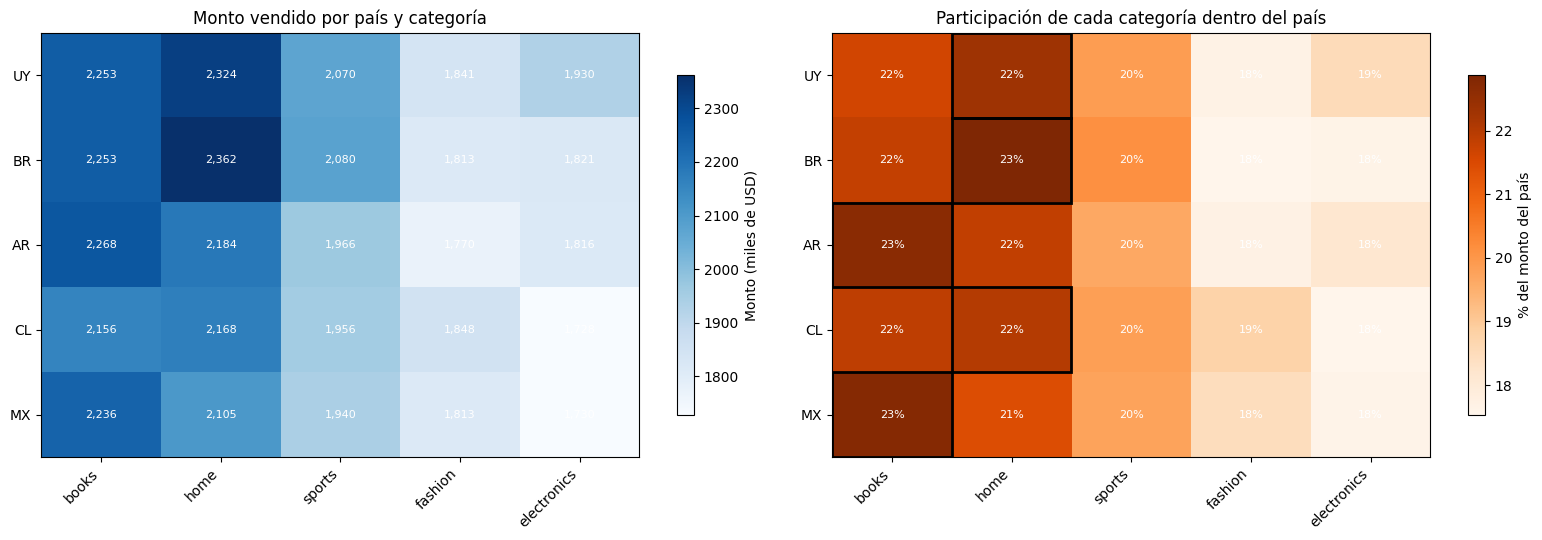

In [0]:
spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA bigdata_federico")

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1) Monto por país × categoría (cast a double: total_amount es DECIMAL)
pc = (
    spark.table("gold_daily_sales")
    .groupBy("country", "category")
    .agg(F.sum("total_amount").cast("double").alias("monto"))
).toPandas()

mat = pc.pivot(index="country", columns="category", values="monto").fillna(0.0)
mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index,
              mat.sum(axis=0).sort_values(ascending=False).index]
share = mat.div(mat.sum(axis=1), axis=0)

# 2) Respuestas en texto
top = pc.loc[pc["monto"].idxmax()]
print(f"Combinación líder: {top.country} × {top.category} → {top.monto:,.2f} USD "
      f"({top.monto / pc['monto'].sum():.1%} del total)\n")

lideres = share.idxmax(axis=1)
print("Categoría líder por país:")
for pais in mat.index:
    cat = lideres[pais]
    print(f"  {pais}: {cat} ({share.loc[pais, cat]:.1%} del país, {mat.loc[pais, cat]:,.0f} USD)")
print("\nCategorías líderes distintas:", lideres.nunique(), "→", sorted(lideres.unique()))

# 3) Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.5 * len(mat) + 3))

def heatmap(ax, data, titulo, fmt, cbar_label, cmap):
    im = ax.imshow(data.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(data.shape[1]))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(data.shape[0]))
    ax.set_yticklabels(data.index)
    vmax = data.values.max()
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i, j]
            ax.text(j, i, fmt(v), ha="center", va="center", fontsize=8,
                    color="white" if v > 0.6 * vmax else "black")
    ax.set_title(titulo)
    fig.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)

heatmap(ax1, mat / 1e3, "Monto vendido por país y categoría",
        lambda v: f"{v:,.0f}", "Monto (miles de USD)", "Blues")
heatmap(ax2, share * 100, "Participación de cada categoría dentro del país",
        lambda v: f"{v:.0f}%", "% del monto del país", "Oranges")

cols = list(share.columns)
for i, pais in enumerate(share.index):
    j = cols.index(lideres[pais])
    ax2.add_patch(patches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))

plt.tight_layout()
plt.show()

La combinacion home / brasil es la que genera mayor monto. La categoria dominante cambia segun el mercado.

## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

     lote   total  aceptadas  rechazadas pct_acept pct_rech ic_inf ic_sup
batch_002   202.0      200.0         2.0    99.01%    0.99%  0.27%  3.54%
batch_003   203.0      201.0         2.0    99.01%    0.99%  0.27%  3.52%
  initial 49999.0    49948.0        51.0    99.90%    0.10%  0.08%  0.13%

Comparación de tasa de rechazo vs. lote de referencia 'batch_002':
  batch_003: 0.99% vs 0.99% → diferencia -0.00 p.p., p-valor 0.9960
  initial: 0.10% vs 0.99% → diferencia -0.89 p.p., p-valor 0.0001


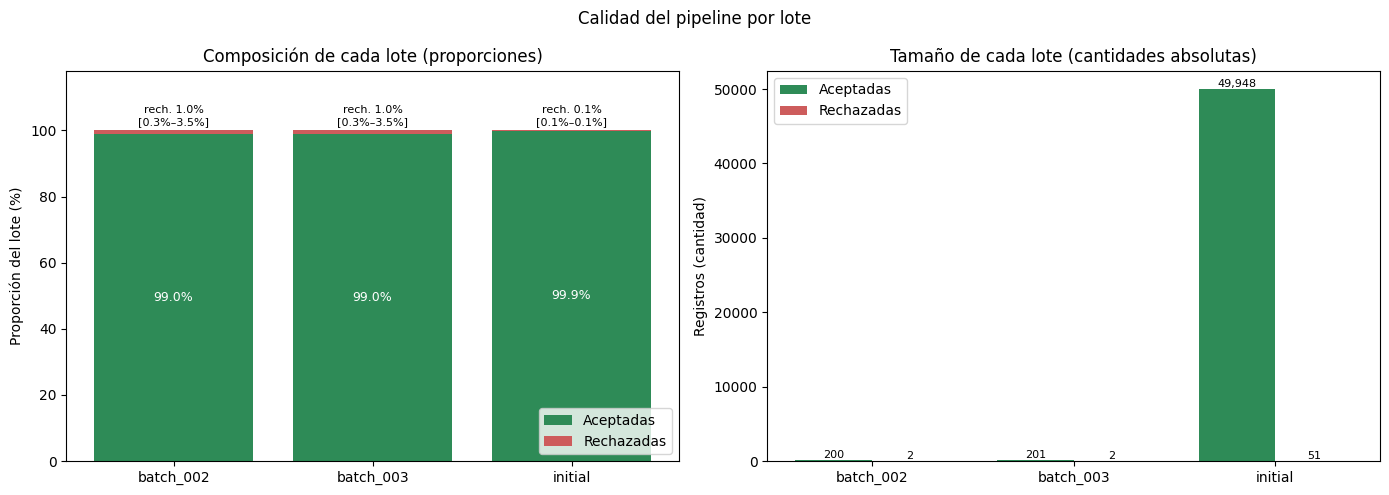

In [0]:
spark.sql("USE CATALOG workspace")
spark.sql("USE SCHEMA bigdata_federico")

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np
from math import erf, sqrt

COL_LOTE = "source_batch_id"
COL_ACEPT = "accepted_transactions"
COL_RECH = "rejected_transactions"

lotes = (
    spark.table("gold_batch_summary")
    .select(
        F.col(COL_LOTE).alias("lote"),
        F.col(COL_ACEPT).cast("double").alias("aceptadas"),
        F.col(COL_RECH).cast("double").alias("rechazadas"),
    )
    .orderBy("lote")
).toPandas()

lotes["total"] = lotes["aceptadas"] + lotes["rechazadas"]
lotes["pct_acept"] = lotes["aceptadas"] / lotes["total"]
lotes["pct_rech"] = lotes["rechazadas"] / lotes["total"]

# IC 95% Wilson para la tasa de rechazo
z = 1.96
n, p = lotes["total"], lotes["pct_rech"]
centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
lotes["ic_inf"], lotes["ic_sup"] = centro - margen, centro + margen

print(lotes[["lote", "total", "aceptadas", "rechazadas", "pct_acept", "pct_rech", "ic_inf", "ic_sup"]]
      .to_string(index=False, formatters={
          "pct_acept": "{:.2%}".format, "pct_rech": "{:.2%}".format,
          "ic_inf": "{:.2%}".format, "ic_sup": "{:.2%}".format}))

# Test z de diferencia de proporciones: cada lote vs. el primero (referencia)
ref = lotes.iloc[0]
print(f"\nComparación de tasa de rechazo vs. lote de referencia '{ref.lote}':")
for _, r in lotes.iloc[1:].iterrows():
    p_pool = (ref.rechazadas + r.rechazadas) / (ref.total + r.total)
    se = sqrt(p_pool * (1 - p_pool) * (1 / ref.total + 1 / r.total))
    zstat = (r.pct_rech - ref.pct_rech) / se if se > 0 else float("nan")
    pval = 2 * (1 - 0.5 * (1 + erf(abs(zstat) / sqrt(2)))) if se > 0 else float("nan")
    print(f"  {r.lote}: {r.pct_rech:.2%} vs {ref.pct_rech:.2%} → diferencia {(r.pct_rech - ref.pct_rech) * 100:+.2f} p.p., p-valor {pval:.4f}")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(lotes))

ax1.bar(x, lotes["pct_acept"] * 100, color="seagreen", label="Aceptadas")
ax1.bar(x, lotes["pct_rech"] * 100, bottom=lotes["pct_acept"] * 100, color="indianred", label="Rechazadas")
for i, r in lotes.iterrows():
    ax1.text(i, r.pct_acept * 50, f"{r.pct_acept:.1%}", ha="center", va="center", color="white", fontsize=9)
    ax1.text(i, 101, f"rech. {r.pct_rech:.1%}\n[{r.ic_inf:.1%}–{r.ic_sup:.1%}]", ha="center", va="bottom", fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(lotes["lote"])
ax1.set_ylabel("Proporción del lote (%)")
ax1.set_ylim(0, 118)
ax1.set_title("Composición de cada lote (proporciones)")
ax1.legend(loc="lower right")

w = 0.38
ax2.bar(x - w/2, lotes["aceptadas"], w, color="seagreen", label="Aceptadas")
ax2.bar(x + w/2, lotes["rechazadas"], w, color="indianred", label="Rechazadas")
for i, r in lotes.iterrows():
    ax2.text(i - w/2, r.aceptadas, f"{r.aceptadas:,.0f}", ha="center", va="bottom", fontsize=8)
    ax2.text(i + w/2, r.rechazadas, f"{r.rechazadas:,.0f}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(lotes["lote"])
ax2.set_ylabel("Registros (cantidad)")
ax2.set_title("Tamaño de cada lote (cantidades absolutas)")
ax2.legend()

fig.suptitle("Calidad del pipeline por lote")
plt.tight_layout()
plt.show()

EL lote inicial tuvo 99.9% de aceptación, mientras que los batch 2 y 3, tuvieron 99.0% de aceptación. La calidad de los baches nuevos es mejor al inicial, tienen menos rechazo en valor absoluto.


## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.